# 🎓 Student Placement Prediction using K-Nearest Neighbors (KNN)

This notebook demonstrates a machine learning model to predict whether a student is likely to be placed based on academic and skill-related features.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv("placement_dataset.csv")
df.head()

,Student_ID,Gender,Age,Department,CGPA,Tenth_Percentage,Twelfth_Percentage,Degree_Percentage,Projects,Internships,Certifications,Coding_Skill,Communication,Aptitude,English,Leadership,Teamwork,Hackathons,Backlogs,Placement
0,1,Male,20,CIVIL,6.71,69,63,61,5,0,6,1,1,45,4,4,9,4,0,No
1,2,Male,25,CIVIL,8.59,81,69,83,4,2,0,3,7,61,5,3,4,2,0,Yes
2,3,Male,23,CSE,7.08,77,93,71,6,0,7,9,2,99,7,2,9,2,5,Yes
3,4,Female,24,IT,8.60,57,97,69,6,2,1,4,2,64,5,8,6,1,2,Yes
4,5,Female,21,CIVIL,6.67,98,96,59,4,1,8,4,3,69,7,5,9,1,5,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          2000 non-null   int64  
 1   Gender              2000 non-null   object 
 2   Age                 2000 non-null   int64  
 3   Department          2000 non-null   object 
 4   CGPA                2000 non-null   float64
 5   Tenth_Percentage    2000 non-null   int64  
 6   Twelfth_Percentage  2000 non-null   int64  
 7   Degree_Percentage   2000 non-null   int64  
 8   Projects            2000 non-null   int64  
 9   Internships         2000 non-null   int64  
 10  Certifications      2000 non-null   int64  
 11  Coding_Skill        2000 non-null   int64  
 12  Communication       2000 non-null   int64  
 13  Aptitude            2000 non-null   int64  
 14  English             2000 non-null   int64  
 15  Leadership          2000 non-null   int64  
 16  Teamwo

In [5]:
df.isnull().sum()

Student_ID            0
Gender                0
Age                   0
Department            0
CGPA                  0
Tenth_Percentage      0
Twelfth_Percentage    0
Degree_Percentage     0
Projects              0
Internships           0
Certifications        0
Coding_Skill          0
Communication         0
Aptitude              0
English               0
Leadership            0
Teamwork              0
Hackathons            0
Backlogs              0
Placement             0
dtype: int64

In [6]:
df["Placement"].value_counts()

Placement
Yes    1303
No      697
Name: count, dtype: int64

In [7]:
label_encoders = {}

for col in ["Gender", "Department"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

target = LabelEncoder()
df["Placement"] = target.fit_transform(df["Placement"])

In [8]:
X = df.drop(["Student_ID","Placement"], axis=1)
y = df["Placement"]

In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [12]:
pred=model.predict(X_test)

accuracy_score(y_test,pred)

0.8225

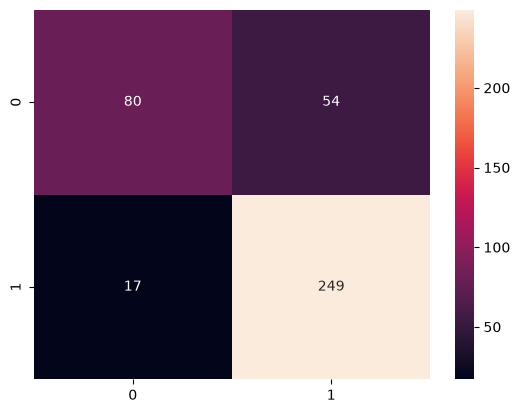

In [13]:
cm=confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt="d")

plt.show()

In [14]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.82      0.60      0.69       134
           1       0.82      0.94      0.88       266

    accuracy                           0.82       400
   macro avg       0.82      0.77      0.78       400
weighted avg       0.82      0.82      0.81       400



In [15]:
joblib.dump(model,"knn_model.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(label_encoders,"label_encoders.pkl")

['label_encoders.pkl']

In [16]:
sample=X_test[0].reshape(1,-1)

model.predict(sample)

array([0])